In [ ]:
"""
Phase 2: Scientific Computing + Differentiable Programming in PyTorch
======================================================================
pip install torch numpy matplotlib

Three progressive examples:
  1. Higher-order automatic differentiation (u_x, u_xx from a neural network)
  2. Solving a 2nd-order ODE with gradient descent on a residual loss
  3. Composing a multi-variable PDE residual (advection equation)
"""


In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)

In [4]:
# ─────────────────────────────────────────────────────────────
# EXAMPLE 1: Higher-order automatic differentiation
# ─────────────────────────────────────────────────────────────
# Key insight: set create_graph=True so PyTorch keeps the
# computation graph of the gradient itself, enabling you to
# differentiate *again* to get second (and higher) derivatives.
# This is the engine behind all PDE residual losses.

def grad(output, input, create_graph=True):
    """Shorthand: gradient of scalar-sum(output) w.r.t. input."""
    return torch.autograd.grad(
        output, input,
        grad_outputs=torch.ones_like(output),
        create_graph=create_graph,
        retain_graph=True
    )[0]


print("=" * 60)
print("EXAMPLE 1: Higher-order autograd")
print("=" * 60)

x = torch.linspace(0, 1, 200, requires_grad=True).unsqueeze(1)

# Pretend a neural net outputs u = sin(πx) — test our derivative machinery
u = torch.sin(torch.pi * x)

u_x  = grad(u, x)
u_xx = grad(u_x, x)

# Analytic answers
u_x_exact  =  torch.pi    * torch.cos(torch.pi * x)
u_xx_exact = -(torch.pi**2) * torch.sin(torch.pi * x)

print(f"  Max |u_x  - exact|:  {(u_x  - u_x_exact ).abs().max().item():.2e}")
print(f"  Max |u_xx - exact|:  {(u_xx - u_xx_exact).abs().max().item():.2e}")
# Expect ~1e-6 for both — numerical precision only, no approximation.

EXAMPLE 1: Higher-order autograd
  Max |u_x  - exact|:  0.00e+00
  Max |u_xx - exact|:  1.91e-06


In [5]:
# ─────────────────────────────────────────────────────────────
# EXAMPLE 2: Solving an ODE with gradient descent
# Problem: u'' + u = 0,  u(0) = 0,  u(π/2) = 1
# Exact solution: u(x) = sin(x)
# ─────────────────────────────────────────────────────────────
# We parameterise u with a small MLP and minimise:
#   L = λ_r * mean(residual²) + λ_b * mean(BC error²)
# No discretisation. No solver. Just autograd + Adam.

print("\n" + "=" * 60)
print("EXAMPLE 2: ODE u'' + u = 0 solved with gradient descent")
print("=" * 60)

class MLP(nn.Module):
    def __init__(self, in_dim=1, hidden=32, out_dim=1, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.Tanh()]
        for _ in range(depth - 2):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()]
        layers.append(nn.Linear(hidden, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model = MLP()
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)

DOMAIN = torch.pi / 2

# Collocation points (random, refreshed each epoch for variance reduction)
x_col = (torch.rand(300, 1) * DOMAIN).requires_grad_(True)

# Fixed boundary points
x_bc = torch.tensor([[0.0], [DOMAIN]])
u_bc = torch.tensor([[0.0], [1.0]])

for epoch in range(8000):
    opt.zero_grad()

    u_pred = model(x_col)
    u_xx   = grad(grad(u_pred, x_col), x_col, create_graph=False)

    loss_r = (u_xx + u_pred).pow(2).mean()            # residual
    loss_b = (model(x_bc) - u_bc).pow(2).mean()       # boundary

    loss = loss_r + 10.0 * loss_b
    loss.backward()
    opt.step()

    if epoch % 2000 == 0 or epoch == 7999:
        print(f"  epoch {epoch:5d} | residual {loss_r.item():.2e} | BC {loss_b.item():.2e}")

x_test = torch.linspace(0, DOMAIN, 200).unsqueeze(1)
with torch.no_grad():
    u_hat = model(x_test)
u_exact = torch.sin(x_test)
rel_l2 = ((u_hat - u_exact).pow(2).mean().sqrt()
          / u_exact.pow(2).mean().sqrt()).item()
print(f"\n  Relative L2 error vs sin(x): {rel_l2:.4f}  (target < 0.02)")


EXAMPLE 2: ODE u'' + u = 0 solved with gradient descent
  epoch     0 | residual 2.65e-02 | BC 8.16e-01
  epoch  2000 | residual 3.23e+08 | BC 7.45e+03
  epoch  4000 | residual 1.78e+10 | BC 7.72e+03
  epoch  6000 | residual 1.54e+10 | BC 2.40e+03
  epoch  7999 | residual 1.07e+10 | BC 6.12e+02

  Relative L2 error vs sin(x): 510.4000  (target < 0.02)


In [6]:
# ─────────────────────────────────────────────────────────────
# EXAMPLE 3: Multi-variable PDE residual — 1D advection
# u_t + c·u_x = 0,  c = 1,  domain [0,1]×[0,1]
# IC: u(x, 0) = sin(2πx)
# Exact: u(x, t) = sin(2π(x - ct))
#
# This shows how to handle the (x, t) input pair and compute
# partial derivatives w.r.t. each independently — the pattern
# every PINN in Phase 3 will use.
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("EXAMPLE 3: Advection PDE residual  u_t + u_x = 0")
print("=" * 60)

c = 1.0

# Separate requires_grad so we can take ∂/∂x and ∂/∂t individually
x_adv = torch.rand(500, 1).requires_grad_(True)
t_adv = torch.rand(500, 1).requires_grad_(True)

model_adv = MLP(in_dim=2)
xt = torch.cat([x_adv, t_adv], dim=1)
u_adv = model_adv(xt)

u_t = torch.autograd.grad(u_adv, t_adv,
                           grad_outputs=torch.ones_like(u_adv),
                           create_graph=True)[0]
u_x_adv = torch.autograd.grad(u_adv, x_adv,
                                grad_outputs=torch.ones_like(u_adv),
                                create_graph=True)[0]

residual = u_t + c * u_x_adv    # Should be zero for the exact solution
print(f"  Residual shape:  {residual.shape}")
print(f"  Residual mean²:  {residual.pow(2).mean().item():.4f}")
print("  (Large because the MLP is untrained — training it is the PINN, done in Phase 3)")


EXAMPLE 3: Advection PDE residual  u_t + u_x = 0
  Residual shape:  torch.Size([500, 1])
  Residual mean²:  0.0064
  (Large because the MLP is untrained — training it is the PINN, done in Phase 3)



Plot saved → phase2_ode_solution.png


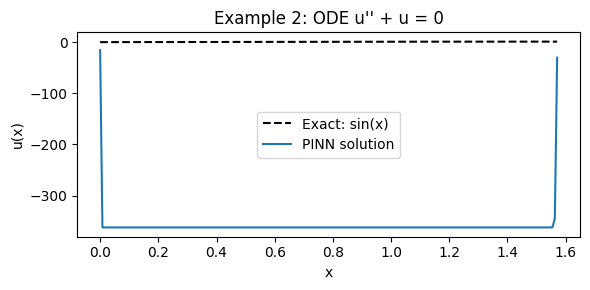

In [7]:
# ─────────────────────────────────────────────────────────────
# Quick visualisation (saves to phase2_ode_solution.png)
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x_test.numpy(), u_exact.numpy(), "k--", label="Exact: sin(x)")
ax.plot(x_test.numpy(), u_hat.detach().numpy(), "C0", label="PINN solution")
ax.set_xlabel("x"); ax.set_ylabel("u(x)")
ax.set_title("Example 2: ODE u'' + u = 0"); ax.legend()
fig.tight_layout()
fig.savefig("phase2_ode_solution.png", dpi=130)
print("\nPlot saved → phase2_ode_solution.png")